# AI Adoption Frontier: Large-Scale Analytics with PySpark



In [ ]:
!pip install pyspark matplotlib seaborn -q

import warnings
warnings.filterwarnings('ignore')
print('Environment ready.')

Environment ready.


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AI_Adoption_Frontier") \
    .master("local[*]") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.sql.ansi.enabled", "false") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} — Ready")

Spark 4.0.2 — Ready



## 2. Data Ingestion & Initial Quality Checks


In [ ]:
# Upload ai_company_adoption.csv
from google.colab import files
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f'Loaded: {CSV_PATH}')

Saving ai_company_adoption.csv to ai_company_adoption.csv
Loaded: ai_company_adoption.csv


In [ ]:
from pyspark.sql.functions import col, count, min as _min, max as _max, avg, stddev, countDistinct

# ============================================================
# Step 1 — Load CSV & Schema Inspection (DataFrame API)
# ============================================================

df_raw = spark.read \
    .option('header', 'true') \
    .option('inferSchema', 'true') \
    .option('mode', 'DROPMALFORMED') \
    .csv(CSV_PATH)

total_rows = df_raw.count()
total_cols = len(df_raw.columns)
print(f'Rows: {total_rows:,}  |  Columns: {total_cols}')
print()

# Schema inspection — every column name + inferred type
print('=== Schema (Spark-inferred types) ===')
df_raw.printSchema()

Rows: 150,000  |  Columns: 43

=== Schema (Spark-inferred types) ===
root
 |-- response_id: integer (nullable = true)
 |-- company_id: string (nullable = true)
 |-- survey_year: integer (nullable = true)
 |-- quarter: string (nullable = true)
 |-- country: string (nullable = true)
 |-- region: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- num_employees: integer (nullable = true)
 |-- annual_revenue_usd_millions: double (nullable = true)
 |-- company_founding_year: integer (nullable = true)
 |-- company_age: integer (nullable = true)
 |-- company_age_group: string (nullable = true)
 |-- ai_adoption_rate: double (nullable = true)
 |-- ai_adoption_stage: string (nullable = true)
 |-- years_using_ai: integer (nullable = true)
 |-- ai_primary_tool: string (nullable = true)
 |-- num_ai_tools_used: integer (nullable = true)
 |-- ai_use_case: string (nullable = true)
 |-- ai_projects_active: integer (nullable = true)
 |-- ai_t

In [ ]:
from pyspark.sql.functions import when, isnan, isnull

# ============================================================
# Step 2 — Data Profiling: Summary Stats + Distinct Counts + Null Audit
# ============================================================

# 2a. Summary statistics for all numeric columns (like df.describe() on steroids)
print('=== Numeric Column Profiling ===')
numeric_cols = [f.name for f in df_raw.schema.fields if f.dataType.typeName() in ('integer', 'double', 'long')]

profile_rows = []
for nc in numeric_cols:
    row = df_raw.select(
        _min(nc).alias('min'),
        _max(nc).alias('max'),
        avg(nc).alias('mean'),
        stddev(nc).alias('stddev'),
        countDistinct(nc).alias('distinct')
    ).collect()[0]
    profile_rows.append((nc, row['min'], row['max'], row['mean'], row['stddev'], row['distinct']))

print(f'  {"Column":<34s} {"Min":>10s} {"Max":>10s} {"Mean":>10s} {"StdDev":>9s} {"Distinct":>8s}')
print(f'  {"-"*85}')
for nc, vmin, vmax, vmean, vstd, vdist in profile_rows:
    print(f'  {nc:<34s} {str(vmin):>10s} {str(vmax):>10s} {str(round(vmean,2)):>10s} {str(round(vstd,2)):>9s} {str(vdist):>8s}')

# 2b. Single-pass missing-value audit across ALL columns
print()
print('=== Missing Value & Completeness Audit ===')
total = df_raw.count()
null_exprs = [
    count(when(col(c).isNull() | (col(c).cast('string') == 'nan'), c)).alias(c)
    for c in df_raw.columns
]
null_row = df_raw.select(null_exprs).collect()[0]

null_pct = {}
issues_found = 0
for c in df_raw.columns:
    n = null_row[c]
    pct = n / total * 100
    null_pct[c] = pct
    if pct > 0:
        issues_found += 1
        print(f'  {c:<38s} : {n:>6,d} nulls  ({pct:5.1f}%)')

print(f'\nCompleteness: {total_cols - issues_found}/{total_cols} columns have zero missing values')

# 2c. Duplicate detection
dup_count = df_raw.count() - df_raw.dropDuplicates().count()
print(f'Duplicate rows: {dup_count:,}')

# 2d. Quick sample peek (first 8 rows, key columns)
print()
print('=== Sample Rows (key business columns) ===')
df_raw.select('company_id', 'survey_year', 'quarter', 'country', 'industry',
              'company_size', 'ai_adoption_rate', 'ai_adoption_stage',
              'ai_maturity_score', 'revenue_growth_percent').show(8, truncate=False)

=== Numeric Column Profiling ===
  Column                                    Min        Max       Mean    StdDev Distinct
  -------------------------------------------------------------------------------------
  response_id                                 1     160000   79961.11  46158.81   150000
  survey_year                              2023       2026     2024.5      1.12        4
  num_employees                              10      19970    2342.38   4754.42     2850
  annual_revenue_usd_millions              1.01    9996.73    1180.35   2391.47     8688
  company_founding_year                    1990       2022    2005.99      9.47       33
  company_age                                 1         36      18.51      9.54       36
  ai_adoption_rate                          0.0      100.0      36.41     14.54     7829
  years_using_ai                              0         10       4.93      2.43       11
  num_ai_tools_used                           1          6       2.32      0.9


## 3. DataFrame API — Core Transformations & Aggregations


In [ ]:
from pyspark.sql.functions import col, avg, count, sum as _sum, max as _max

# ============================================================
# 1. Filter — companies with AI adoption rate > 50%
# ============================================================
print('=== Filter: High AI Adopters (adoption > 50%) ===')
high_adopters = df_raw.filter(col('ai_adoption_rate') > 50)
high_adopters.select('company_id', 'industry', 'ai_adoption_rate',
                     'ai_maturity_score', 'revenue_growth_percent').show(8, truncate=False)

# ============================================================
# 2. GroupBy + Aggregation — industry-level business summary
# ============================================================
print('\n=== GroupBy + Agg: Industry-Level Summary ===')
industry_stats = df_raw.groupBy('industry') \
    .agg(
        avg('ai_adoption_rate').alias('AvgAdoption'),
        avg('ai_maturity_score').alias('AvgMaturity'),
        avg('revenue_growth_percent').alias('AvgRevGrowth'),
        avg('cost_reduction_percent').alias('AvgCostReduction'),
        count('*').alias('FirmCount')
    )
industry_stats.show(10, truncate=False)

# ============================================================
# 3. OrderBy — rank top industries by AI maturity
# ============================================================
print('\n=== OrderBy: Top 10 Industries by AI Maturity ===')
industry_stats.orderBy(col('AvgMaturity').desc()).show(10, truncate=False)

# ============================================================
# 4. Multi-dimensional GroupBy — industry x company_size
# ============================================================
print('\n=== GroupBy: Industry x Company Size (Adoption + Maturity) ===')
segment_stats = df_raw.groupBy('industry', 'company_size') \
    .agg(
        avg('ai_adoption_rate').alias('AvgAdoption'),
        avg('ai_maturity_score').alias('AvgMaturity'),
        count('*').alias('Firms')
    ) \
    .filter(col('Firms') >= 10) \
    .orderBy(col('AvgAdoption').desc())
segment_stats.show(10, truncate=False)

=== Filter: High AI Adopters (adoption > 50%) ===
+----------+---------+----------------+-----------------+----------------------+
|company_id|industry |ai_adoption_rate|ai_maturity_score|revenue_growth_percent|
+----------+---------+----------------+-----------------+----------------------+
|COMP-00001|Education|57.42           |0.459            |10.72                 |
|COMP-00001|Education|52.95           |0.427            |11.45                 |
|COMP-00001|Education|52.61           |0.453            |3.51                  |
|COMP-00002|Finance  |59.32           |0.424            |4.79                  |
|COMP-00002|Finance  |61.6            |0.417            |1.43                  |
|COMP-00002|Finance  |50.94           |0.465            |0.88                  |
|COMP-00002|Finance  |73.84           |0.558            |3.22                  |
|COMP-00002|Finance  |54.07           |0.488            |8.15                  |
+----------+---------+----------------+-----------------+--


## 4. Data Preprocessing Pipeline


In [ ]:
from pyspark.sql.types import DoubleType, IntegerType

# ============================================================
# Step 1 — Type Correction: Force-cast all numeric columns
# ============================================================

numeric_keys = [
    'ai_adoption_rate', 'ai_maturity_score', 'ai_failure_rate',
    'ai_budget_percentage', 'revenue_growth_percent', 'cost_reduction_percent',
    'innovation_score', 'productivity_change_percent', 'task_automation_rate',
    'ai_investment_per_employee', 'regulatory_compliance_score',
    'ai_risk_management_score', 'employee_satisfaction_score'
]

df_corrected = df_raw
for c in numeric_keys:
    df_corrected = df_corrected.withColumn(c, col(c).cast(DoubleType()))

print(f'Type-corrected {len(numeric_keys)} numeric columns → DoubleType')

Type-corrected 13 numeric columns → DoubleType


In [ ]:
from pyspark.sql.functions import when, lit

# ============================================================
# Step 2 — Imputation: Numeric → Median | Categorical → 'Unknown'
# ============================================================

df_corrected.cache()
df_clean = df_corrected

for nc in numeric_keys:
    if null_pct.get(nc, 0) > 0:
        med = df_clean.stat.approxQuantile(nc, [0.5], 0.005)[0]
        df_clean = df_clean.fillna({nc: med})

cat_cols = ['country', 'region', 'industry', 'company_size', 'ai_adoption_stage',
            'ai_use_case', 'data_privacy_level', 'ai_ethics_committee']
for cc in cat_cols:
    if cc in df_clean.columns and null_pct.get(cc, 0) > 0:
        df_clean = df_clean.fillna({cc: 'Unknown'})

# Drop rows missing the 3 core target columns
df_clean = df_clean.dropna(subset=['ai_adoption_rate', 'ai_maturity_score', 'ai_adoption_stage'])
post_count = df_clean.count()
print(f'After imputation & cleaning: {post_count:,} rows (removed {total - post_count:,})')

# ============================================================
# Step 3 — Outlier Detection (IQR method, BOOLEAN tag — preserve data)
# ============================================================

outlier_cols = ['ai_adoption_rate', 'ai_maturity_score', 'revenue_growth_percent',
                'cost_reduction_percent', 'innovation_score', 'productivity_change_percent']

print()
print('=== Outlier Analysis (IQR method) ===')
for oc in outlier_cols:
    q1, q3 = df_clean.stat.approxQuantile(oc, [0.25, 0.75], 0.005)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    tag = f'{oc}_outlier'
    df_clean = df_clean.withColumn(
        tag, when((col(oc) < lower) | (col(oc) > upper), lit(True)).otherwise(lit(False))
    )
    cnt = df_clean.filter(col(tag)).count()
    print(f'  {oc:<32s} : {cnt:>6,d} outliers ({cnt/post_count*100:5.1f}%)  [{lower:.2f}, {upper:.2f}]')

print()
print('Outliers TAGGED (Boolean column) — not removed; extremes carry analytical insight.')

After imputation & cleaning: 150,000 rows (removed 0)

=== Outlier Analysis (IQR method) ===
  ai_adoption_rate                 :    504 outliers (  0.3%)  [-3.37, 75.86]
  ai_maturity_score                :    597 outliers (  0.4%)  [-0.03, 0.71]
  revenue_growth_percent           :    569 outliers (  0.4%)  [-10.38, 19.34]
  cost_reduction_percent           :    543 outliers (  0.4%)  [-5.39, 14.61]
  innovation_score                 :    443 outliers (  0.3%)  [31.00, 79.00]
  productivity_change_percent      :    543 outliers (  0.4%)  [-7.00, 25.16]

Outliers TAGGED (Boolean column) — not removed; extremes carry analytical insight.


In [ ]:
from pyspark.sql.functions import round, concat_ws

# ============================================================
# Step 4 — Feature Engineering: 9 Compound Business Metrics
# ============================================================

df_fe = df_clean \
    .withColumn('year_quarter',
        concat_ws('-Q', col('survey_year').cast('string'), col('quarter'))) \
    .withColumn('jobs_net_change',
        col('jobs_created').cast('int') - col('jobs_displaced').cast('int')) \
    .withColumn('workforce_resilience',
        round(col('reskilled_employees') / (col('jobs_displaced') + lit(1)), 2)) \
    .withColumn('ai_investment_efficiency',
        round(col('ai_maturity_score') / (col('ai_budget_percentage') + lit(0.1)), 2)) \
    .withColumn('productivity_per_ai_tool',
        round(col('productivity_change_percent') / (col('num_ai_tools_used') + lit(1)), 2)) \
    .withColumn('automation_leverage',
        round(col('time_saved_per_week') * col('task_automation_rate') / lit(100), 2)) \
    .withColumn('governance_index',
        round((col('regulatory_compliance_score') + col('ai_risk_management_score')) / lit(2), 2)) \
    .withColumn('has_ethics_committee',
        when(col('ai_ethics_committee') == 'Yes', lit(1)).otherwise(lit(0))) \
    .withColumn('high_adopter',
        when(col('ai_adoption_rate') >= lit(50), lit(1)).otherwise(lit(0)))

print('Derived features:')
for d in ['year_quarter', 'jobs_net_change', 'workforce_resilience',
          'ai_investment_efficiency', 'productivity_per_ai_tool',
          'automation_leverage', 'governance_index', 'has_ethics_committee', 'high_adopter']:
    print(f'  + {d}')

df_fe.cache()
fe_count = df_fe.count()
print(f'\nFeature-enriched DataFrame: {fe_count:,} rows x {len(df_fe.columns)} columns')

Derived features:
  + year_quarter
  + jobs_net_change
  + workforce_resilience
  + ai_investment_efficiency
  + productivity_per_ai_tool
  + automation_leverage
  + governance_index
  + has_ethics_committee
  + high_adopter

Feature-enriched DataFrame: 150,000 rows x 58 columns



## 5. Exploratory Data Analysis


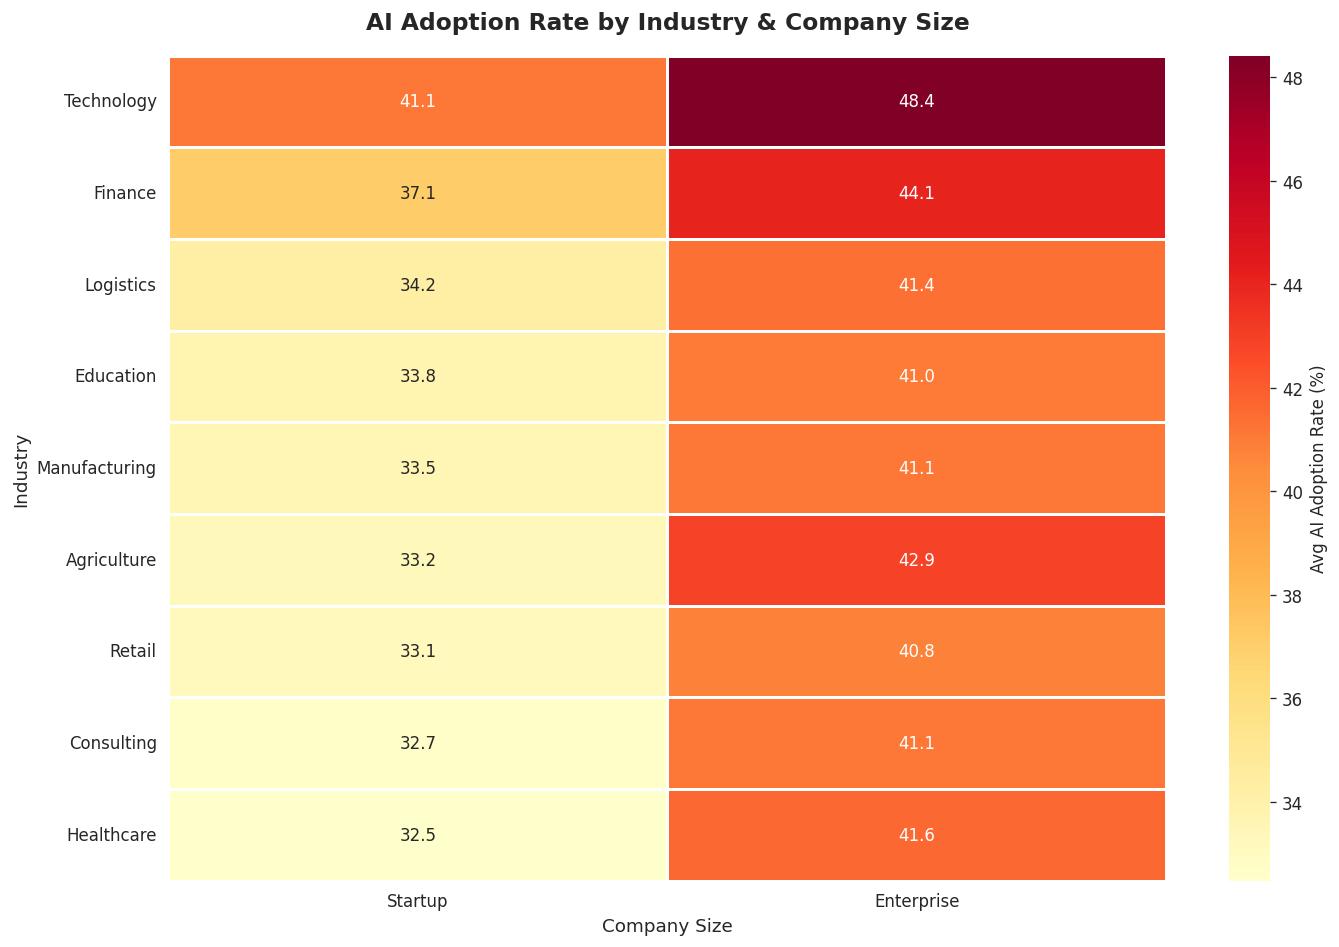

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# --- Viz 1: Heatmap — AI Adoption by Industry x Company Size ---
heat_agg = (df_fe
    .groupBy('industry', 'company_size')
    .agg({'ai_adoption_rate': 'mean', 'ai_maturity_score': 'mean', '*': 'count'})
    .withColumnRenamed('avg(ai_adoption_rate)', 'avg_adoption')
    .withColumnRenamed('avg(ai_maturity_score)', 'avg_maturity')
    .withColumnRenamed('count(1)', 'n')
    .filter(col('n') >= 10)
    .toPandas())

pivot = heat_agg.pivot_table(index='industry', columns='company_size',
                              values='avg_adoption', aggfunc='mean')
size_order = ['Startup', 'SME', 'Enterprise']
pivot = pivot.reindex(columns=[s for s in size_order if s in pivot.columns])
pivot = pivot.sort_values(by=pivot.columns[0], ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.8,
            cbar_kws={'label': 'Avg AI Adoption Rate (%)'}, ax=ax)
ax.set_title('AI Adoption Rate by Industry & Company Size', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Company Size', fontsize=11)
ax.set_ylabel('Industry', fontsize=11)
plt.tight_layout()
plt.show()


## 6. Spark SQL — Temp Views, JOINs & Subqueries


In [ ]:
# Register temp view from the feature-enriched DataFrame
df_fe.createOrReplaceTempView('ai_survey')

# ============================================================
# 1. Basic SELECT with Aggregation — industry-level KPIs
# ============================================================
print('=== Spark SQL: Industry Aggregation ===')
result1 = spark.sql('''
    SELECT industry,
           COUNT(*) AS Firms,
           ROUND(AVG(ai_adoption_rate), 1) AS AvgAdoption,
           ROUND(AVG(ai_maturity_score), 3) AS AvgMaturity,
           ROUND(AVG(revenue_growth_percent), 1) AS AvgRevGrowth,
           ROUND(AVG(ai_investment_efficiency), 2) AS AvgInvestEff
    FROM ai_survey
    GROUP BY industry
    ORDER BY AvgMaturity DESC
''')
result1.show(10, truncate=False)

# ============================================================
# 2. Subquery — companies above average AI maturity
# ============================================================
print('\n=== Spark SQL: Subquery — Above-Average Maturity Companies ===')
result2 = spark.sql('''
    SELECT company_id, industry, ai_adoption_rate,
           ROUND(ai_maturity_score, 3) AS ai_maturity_score,
           ROUND(ai_investment_efficiency, 2) AS invest_eff
    FROM ai_survey
    WHERE ai_maturity_score > (SELECT AVG(ai_maturity_score) FROM ai_survey)
    ORDER BY ai_maturity_score DESC
    LIMIT 10
''')
result2.show(10, truncate=False)

# ============================================================
# 3. JOIN — adoption stage labels x industry breakdown
# ============================================================
# Create a stage label lookup table
stage_lookup = spark.createDataFrame(
    [('pilot', 'Stage 1: Pilot'), ('partial', 'Stage 2: Partial'), ('full', 'Stage 3: Full')],
    ['stage_key', 'stage_label']
)
stage_lookup.createOrReplaceTempView('stage_labels')

print('\n=== Spark SQL: JOIN — Adoption Stage with Business Labels ===')
result3 = spark.sql('''
    SELECT a.industry, s.stage_label, COUNT(*) AS FirmCount,
           ROUND(AVG(a.ai_maturity_score), 3) AS AvgMaturity,
           ROUND(AVG(a.revenue_growth_percent), 1) AS AvgRevGrowth
    FROM ai_survey a
    INNER JOIN stage_labels s ON a.ai_adoption_stage = s.stage_key
    GROUP BY a.industry, s.stage_label
    ORDER BY a.industry, s.stage_label
''')
result3.show(15, truncate=False)

=== Spark SQL: Industry Aggregation ===
+-------------+-----+-----------+-----------+------------+------------+
|industry     |Firms|AvgAdoption|AvgMaturity|AvgRevGrowth|AvgInvestEff|
+-------------+-----+-----------+-----------+------------+------------+
|Technology   |21107|42.5       |0.41       |5.6         |0.03        |
|Finance      |20166|38.3       |0.355      |4.8         |0.04        |
|Education    |15172|35.2       |0.334      |4.3         |0.04        |
|Agriculture  |15570|35.3       |0.332      |4.4         |0.04        |
|Logistics    |12961|35.3       |0.332      |4.5         |0.04        |
|Manufacturing|17501|34.7       |0.329      |4.4         |0.04        |
|Healthcare   |18642|34.6       |0.328      |4.2         |0.05        |
|Consulting   |12504|34.5       |0.328      |4.3         |0.05        |
|Retail       |16377|34.7       |0.327      |4.5         |0.04        |
+-------------+-----+-----------+-----------+------------+------------+


=== Spark SQL: Subquer

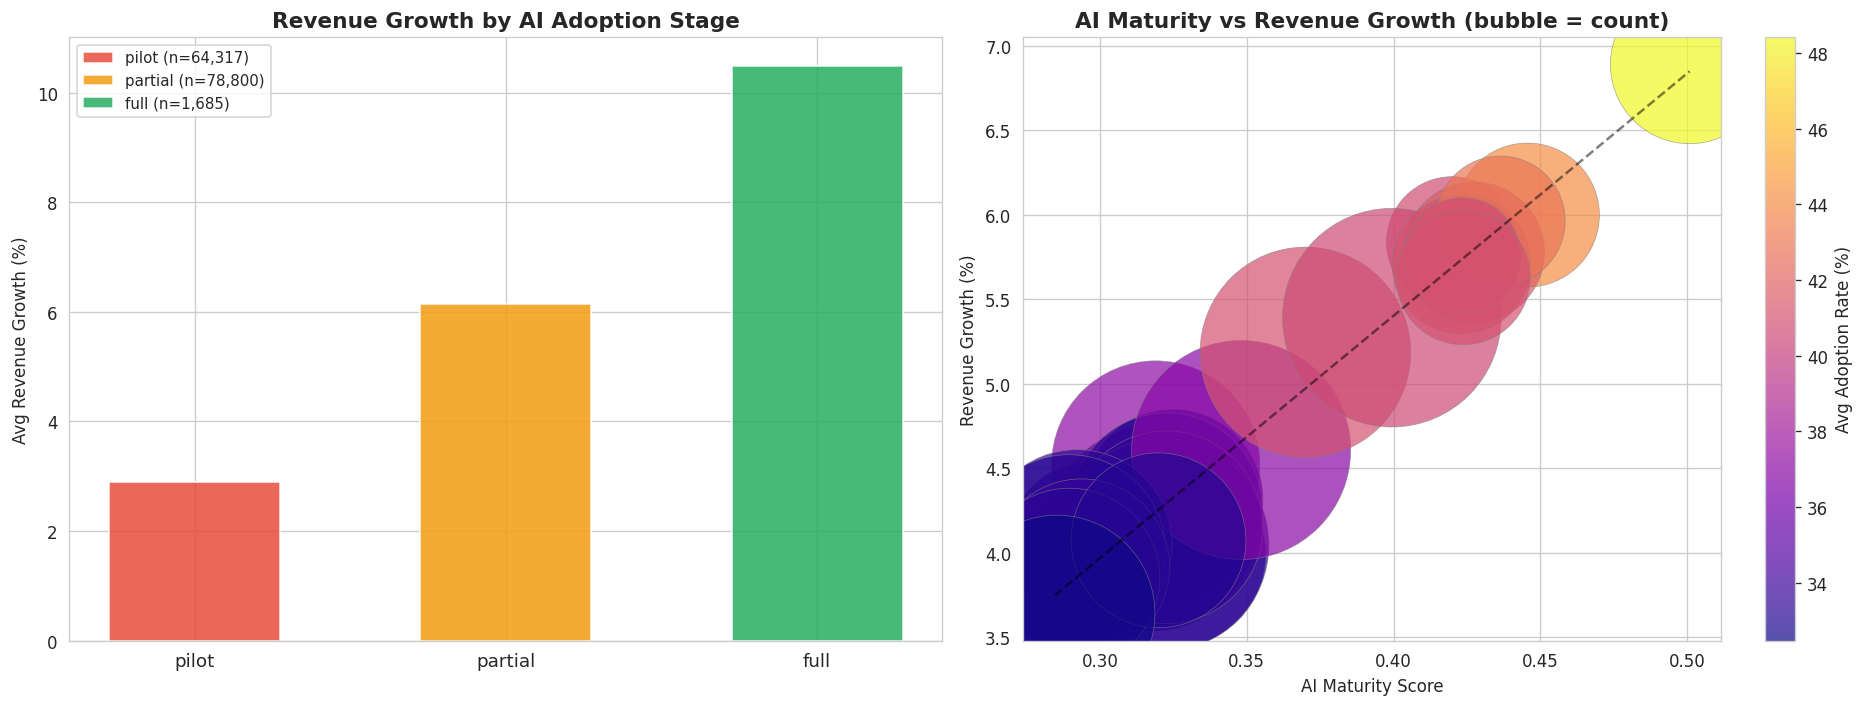

In [ ]:
# --- Viz 2: Revenue Growth vs AI Maturity (Bar + Bubble) ---
stage_pd = df_fe \
    .groupBy('ai_adoption_stage') \
    .agg({'ai_maturity_score': 'mean', 'revenue_growth_percent': 'mean',
          'cost_reduction_percent': 'mean', 'innovation_score': 'mean', '*': 'count'}) \
    .withColumnRenamed('avg(ai_maturity_score)', 'avg_maturity') \
    .withColumnRenamed('avg(revenue_growth_percent)', 'avg_rev_growth') \
    .withColumnRenamed('avg(cost_reduction_percent)', 'avg_cost_reduction') \
    .withColumnRenamed('avg(innovation_score)', 'avg_innovation') \
    .withColumnRenamed('count(1)', 'cnt') \
    .toPandas()

bubble_pd = df_fe \
    .groupBy('industry', 'company_size') \
    .agg({'ai_maturity_score': 'mean', 'revenue_growth_percent': 'mean',
          'ai_adoption_rate': 'mean', '*': 'count'}) \
    .withColumnRenamed('avg(ai_maturity_score)', 'maturity') \
    .withColumnRenamed('avg(revenue_growth_percent)', 'rev_growth') \
    .withColumnRenamed('avg(ai_adoption_rate)', 'adoption') \
    .withColumnRenamed('count(1)', 'n') \
    .filter(col('n') >= 10) \
    .toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

stages = ['pilot', 'partial', 'full']
colors = ['#E74C3C', '#F39C12', '#27AE60']
for i, stage in enumerate(stages):
    row = stage_pd[stage_pd['ai_adoption_stage'] == stage]
    if len(row) > 0:
        ax1.bar(i, row['avg_rev_growth'].values[0], color=colors[i],
                alpha=0.85, width=0.55, label=f"{stage} (n={row['cnt'].values[0]:,})")
ax1.set_title('Revenue Growth by AI Adoption Stage', fontsize=13, fontweight='bold')
ax1.set_ylabel('Avg Revenue Growth (%)')
ax1.set_xticks(range(len(stages)))
ax1.set_xticklabels(stages, fontsize=11)
ax1.legend(fontsize=9)

sc = ax2.scatter(bubble_pd['maturity'], bubble_pd['rev_growth'],
    s=bubble_pd['n'] * 2, c=bubble_pd['adoption'],
    cmap='plasma', alpha=0.7, edgecolors='grey', linewidth=0.4)
plt.colorbar(sc, ax=ax2).set_label('Avg Adoption Rate (%)')
ax2.set_xlabel('AI Maturity Score')
ax2.set_ylabel('Revenue Growth (%)')
ax2.set_title('AI Maturity vs Revenue Growth (bubble = count)', fontsize=13, fontweight='bold')
if len(bubble_pd) > 2:
    z = np.polyfit(bubble_pd['maturity'], bubble_pd['rev_growth'], 1)
    x_line = np.linspace(bubble_pd['maturity'].min(), bubble_pd['maturity'].max(), 50)
    ax2.plot(x_line, np.polyval(z, x_line), '--', color='black', alpha=0.5, lw=1.5)

plt.tight_layout()
plt.show()

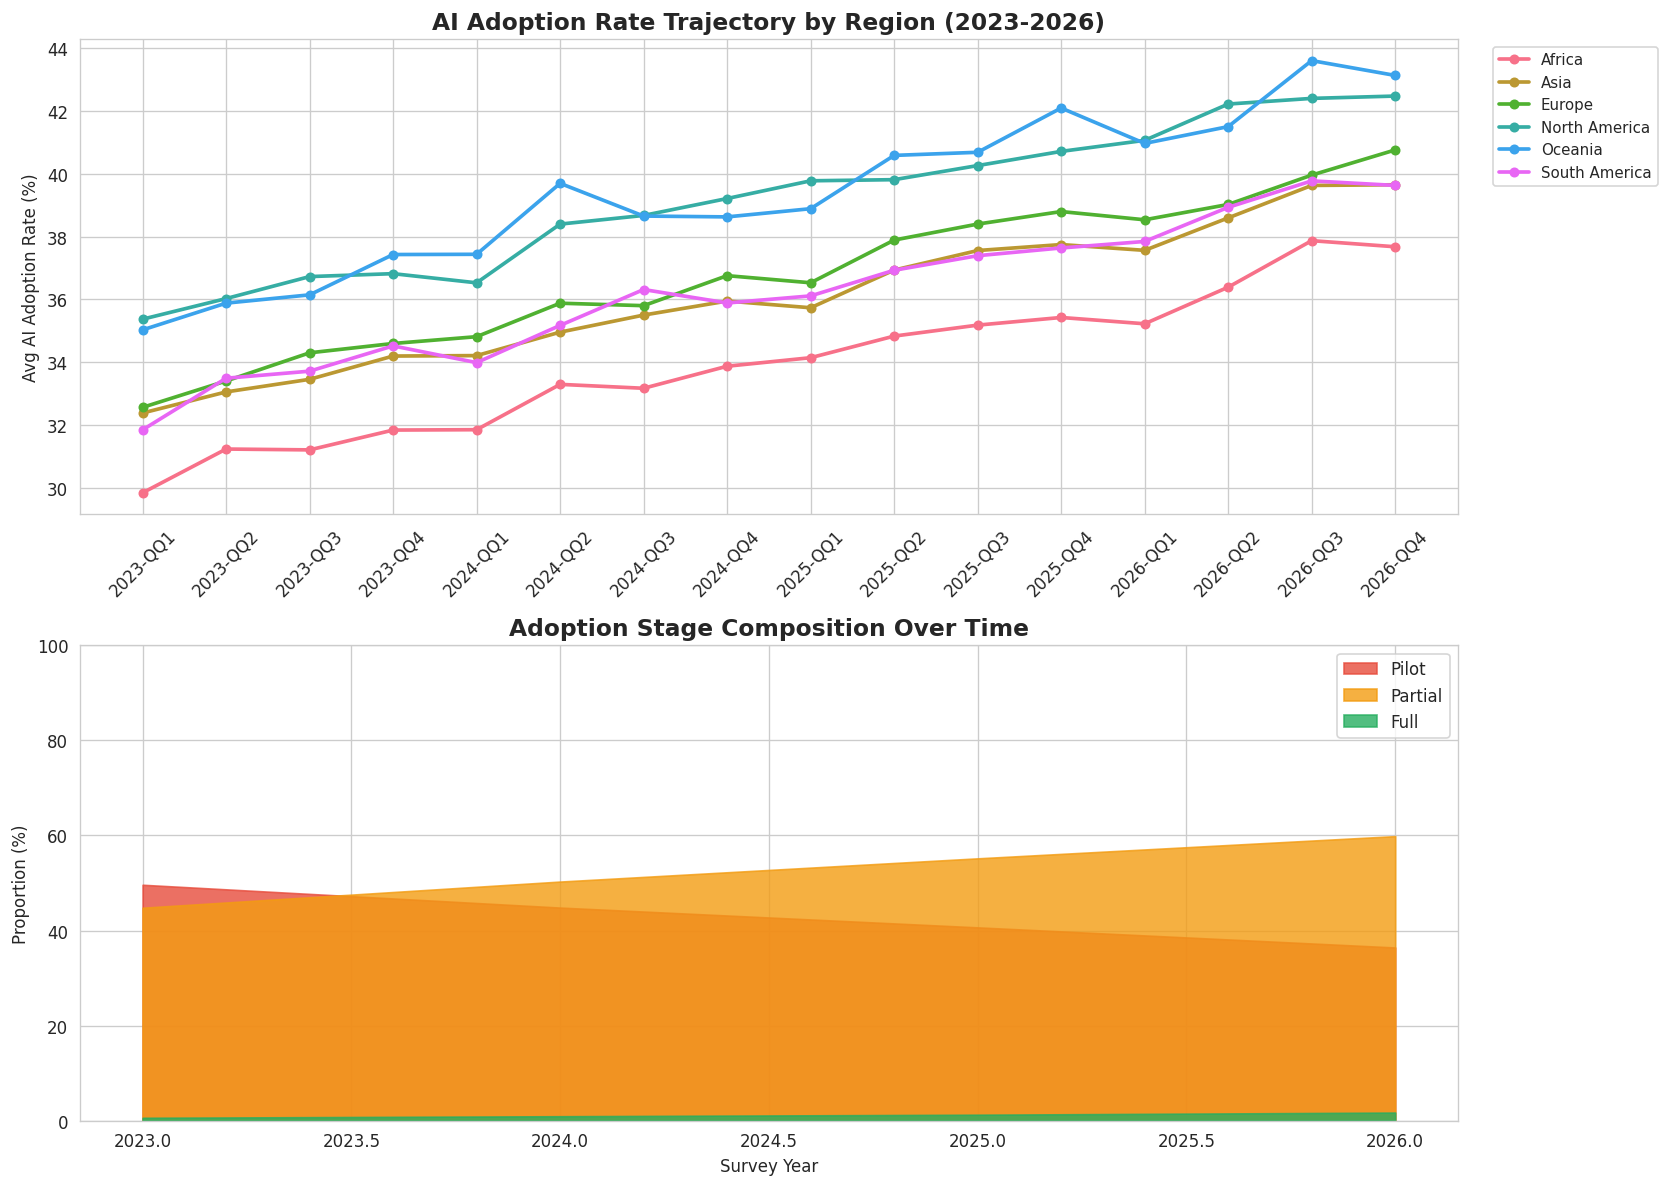

In [ ]:
# --- Viz 3: Temporal Trends by Region + Adoption Stage Composition ---
ts_pd = df_fe \
    .groupBy('survey_year', 'quarter', 'region') \
    .agg({'ai_adoption_rate': 'mean', 'ai_maturity_score': 'mean',
          'innovation_score': 'mean'}) \
    .withColumnRenamed('avg(ai_adoption_rate)', 'avg_adoption') \
    .withColumnRenamed('avg(ai_maturity_score)', 'avg_maturity') \
    .withColumnRenamed('avg(innovation_score)', 'avg_innovation') \
    .toPandas()
ts_pd['time_label'] = ts_pd['survey_year'].astype(str) + '-Q' + ts_pd['quarter'].astype(str)
ts_pd = ts_pd.sort_values(['region', 'survey_year', 'quarter'])

stage_comp = df_fe \
    .groupBy('survey_year', 'ai_adoption_stage') \
    .agg({'*': 'count'}).withColumnRenamed('count(1)', 'cnt').toPandas()
stage_pivot = stage_comp.pivot_table(index='survey_year', columns='ai_adoption_stage',
                                      values='cnt', aggfunc='sum', fill_value=0)
stage_pivot = stage_pivot.div(stage_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

regions_list = sorted(ts_pd['region'].unique())
palette = sns.color_palette('husl', len(regions_list))
for i, region in enumerate(regions_list):
    subset = ts_pd[ts_pd['region'] == region]
    ax1.plot(subset['time_label'], subset['avg_adoption'], 'o-',
             color=palette[i], lw=2.2, markersize=5, label=region)
ax1.set_title('AI Adoption Rate Trajectory by Region (2023-2026)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Avg AI Adoption Rate (%)')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax1.tick_params(axis='x', rotation=45)

stage_colors = {'pilot': '#E74C3C', 'partial': '#F39C12', 'full': '#27AE60'}
for stage in ['pilot', 'partial', 'full']:
    if stage in stage_pivot.columns:
        ax2.fill_between(stage_pivot.index, 0, stage_pivot[stage],
                         label=stage.capitalize(), alpha=0.8, color=stage_colors.get(stage))
ax2.set_title('Adoption Stage Composition Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Survey Year')
ax2.set_ylabel('Proportion (%)')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()


## 7. Advanced Spark SQL (CUBE) & Window Functions


In [ ]:
df_fe.createOrReplaceTempView('ai_adoption')

# --- Query 1: CUBE — region x industry multi-dimensional rollup ---
print('=== CUBE: Region x Industry Rollup ===')
cube_sql = '''
SELECT
    COALESCE(region,   '-- ALL --') AS region,
    COALESCE(industry, '-- ALL --') AS industry,
    ROUND(AVG(ai_adoption_rate), 2)       AS avg_adoption_pct,
    ROUND(AVG(ai_maturity_score), 3)      AS avg_maturity,
    ROUND(AVG(revenue_growth_percent), 2) AS avg_rev_growth_pct,
    ROUND(AVG(governance_index), 2)       AS avg_governance,
    COUNT(*)                               AS response_cnt
FROM ai_adoption
GROUP BY CUBE(region, industry)
ORDER BY response_cnt DESC
LIMIT 15
'''
spark.sql(cube_sql).show(15, truncate=False)

# --- Query 2: Window Functions — RANK + LAG + Rolling Average ---
print('\n=== Window: Top-5 per Industry (RANK) + QoQ Delta (LAG) + Rolling Avg ===')
window_sql = '''
WITH ranked AS (
    SELECT
        company_id, industry, region, survey_year, quarter,
        ai_adoption_rate, ai_maturity_score, governance_index,
        RANK() OVER (
            PARTITION BY industry ORDER BY ai_maturity_score DESC
        ) AS maturity_rank,
        LAG(ai_adoption_rate) OVER (
            PARTITION BY company_id ORDER BY survey_year, quarter
        ) AS prev_q_adoption,
        ROUND(AVG(ai_maturity_score) OVER (
            PARTITION BY company_id ORDER BY survey_year, quarter
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 3) AS rolling_3q_maturity
    FROM ai_adoption
)
SELECT company_id, industry, survey_year, quarter,
       ai_adoption_rate,
       prev_q_adoption,
       ROUND(ai_adoption_rate - prev_q_adoption, 2) AS qoq_delta,
       ai_maturity_score,
       rolling_3q_maturity,
       maturity_rank
FROM ranked
WHERE maturity_rank <= 5
ORDER BY industry, maturity_rank
'''
spark.sql(window_sql).show(25, truncate=False)

# --- Query 3: Ethics Committee — does governance reduce failure? ---
print('\n=== Ethics Committee Impact Analysis ===')
ethics_sql = '''
SELECT region, ai_ethics_committee,
       COUNT(*) AS firms,
       ROUND(AVG(ai_adoption_rate), 2)        AS avg_adoption,
       ROUND(AVG(ai_maturity_score), 3)       AS avg_maturity,
       ROUND(AVG(ai_failure_rate), 2)         AS avg_failure_rate,
       ROUND(AVG(governance_index), 2)        AS avg_governance,
       ROUND(AVG(ai_investment_efficiency), 2) AS avg_invest_eff
FROM ai_adoption
GROUP BY region, ai_ethics_committee
ORDER BY region, ai_ethics_committee
'''
spark.sql(ethics_sql).show(15, truncate=False)

=== CUBE: Region x Industry Rollup ===
+-------------+-------------+----------------+------------+------------------+--------------+------------+
|region       |industry     |avg_adoption_pct|avg_maturity|avg_rev_growth_pct|avg_governance|response_cnt|
+-------------+-------------+----------------+------------+------------------+--------------+------------+
|-- ALL --    |-- ALL --    |36.41           |0.345       |4.61              |64.98         |150000      |
|Asia         |-- ALL --    |36.07           |0.342       |4.55              |64.74         |49727       |
|Europe       |-- ALL --    |36.75           |0.348       |4.65              |66.58         |40835       |
|-- ALL --    |Technology   |42.47           |0.41        |5.63              |65.89         |21107       |
|-- ALL --    |Finance      |38.35           |0.355       |4.83              |65.14         |20166       |
|South America|-- ALL --    |36.19           |0.341       |4.55              |63.86         |19909       


## 8. KMeans Clustering — Company Segmentation



=== Elbow Method: KMeans Cost for k = 2..8 ===
  k=2  within-set SSE = 1246109.1935
  k=3  within-set SSE = 1098500.6984
  k=4  within-set SSE = 1036712.2201
  k=5  within-set SSE = 998600.1325
  k=6  within-set SSE = 944501.4924
  k=7  within-set SSE = 860451.8874
  k=8  within-set SSE = 805748.8397


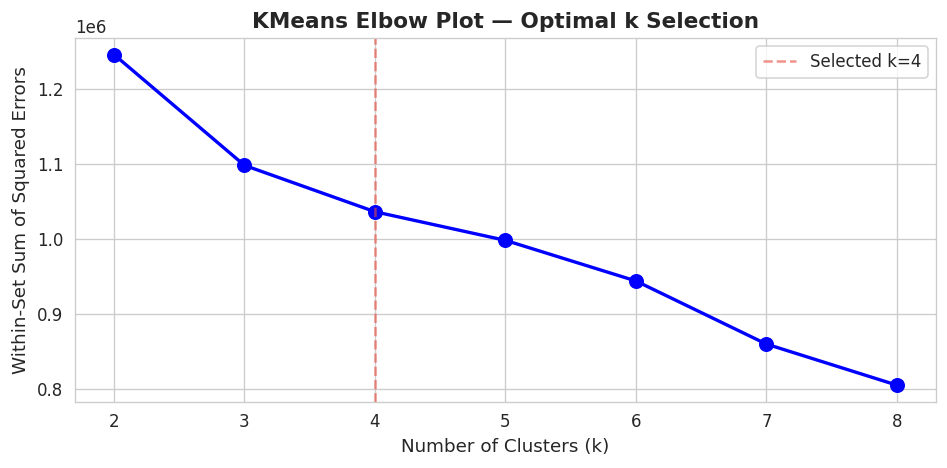

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

# --- Step 1: Assemble & scale clustering features ---
cluster_features = [
    'ai_adoption_rate', 'ai_maturity_score', 'ai_budget_percentage',
    'ai_investment_per_employee', 'ai_training_hours', 'num_ai_tools_used',
    'ai_projects_active', 'innovation_score', 'governance_index',
    'productivity_change_percent', 'task_automation_rate', 'ai_investment_efficiency'
]

cluster_assembler = VectorAssembler(
    inputCols=cluster_features, outputCol='cluster_raw', handleInvalid='skip'
)
cluster_scaler = StandardScaler(
    inputCol='cluster_raw', outputCol='cluster_features', withStd=True, withMean=True
)

# --- Step 2: Elbow method — find optimal k ---
print('=== Elbow Method: KMeans Cost for k = 2..8 ===')
df_cluster_prep = cluster_assembler.transform(df_fe)
scaler_model = cluster_scaler.fit(df_cluster_prep)
df_cluster_scaled = scaler_model.transform(df_cluster_prep).cache()

costs = []
for k in range(2, 9):
    kmeans = KMeans(k=k, featuresCol='cluster_features', seed=42, maxIter=50, initMode='k-means||')
    model = kmeans.fit(df_cluster_scaled)
    costs.append((k, model.summary.trainingCost))
    print(f'  k={k}  within-set SSE = {model.summary.trainingCost:.4f}')

# Plot elbow
k_vals, cost_vals = zip(*costs)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_vals, cost_vals, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Within-Set Sum of Squared Errors', fontsize=11)
ax.set_title('KMeans Elbow Plot — Optimal k Selection', fontsize=13, fontweight='bold')
ax.axvline(x=4, color='#E74C3C', linestyle='--', alpha=0.6, linewidth=1.5, label='Selected k=4')
ax.legend()
plt.tight_layout()
plt.show()

=== Cluster Profiles: AI Adoption Archetypes ===
             archetype  firms  avg_adoption_pct  avg_maturity  avg_rev_growth_pct  avg_invest_eff  avg_governance  avg_failure_rate  avg_productivity
            AI Leaders  22091              57.2         0.550                 8.4            0.04           68.71              17.4              16.7
     Emerging Adopters  48176              43.4         0.411                 5.8            0.04           66.14              22.3              11.7
Cautious Experimenters  51291              31.4         0.293                 3.5            0.04           64.11              28.5               7.2
    Untapped Potential  28442              17.4         0.166                 1.5            0.06           61.69              33.3               3.2

=== Top 3 Industries per Cluster ===

--- Emerging Adopters (Cluster 0) ---
+----------+----+
|industry  |n   |
+----------+----+
|Technology|7952|
|Finance   |6883|
|Healthcare|5566|
+----------+----

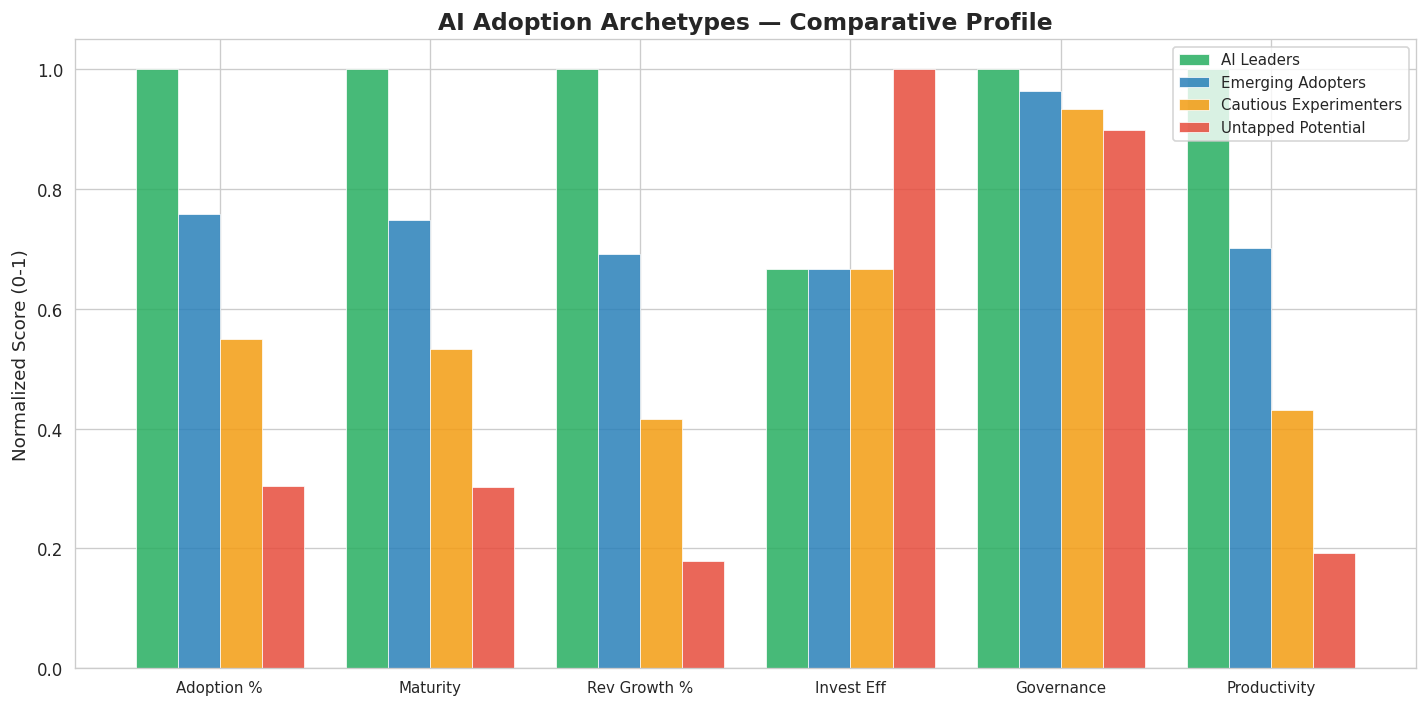

In [ ]:
# --- Step 3: Fit final KMeans with k=4 ---
optimal_k = 4
final_kmeans = KMeans(k=optimal_k, featuresCol='cluster_features', seed=42, maxIter=50)
kmeans_model = final_kmeans.fit(df_cluster_scaled)
df_clustered = kmeans_model.transform(df_cluster_scaled).cache()

# --- Step 4: Profile each cluster — business archetype analysis ---
print('=== Cluster Profiles: AI Adoption Archetypes ===')
cluster_profile = df_clustered.groupBy('prediction').agg(
    count('*').alias('firms'),
    round(avg('ai_adoption_rate'), 1).alias('avg_adoption_pct'),
    round(avg('ai_maturity_score'), 3).alias('avg_maturity'),
    round(avg('revenue_growth_percent'), 1).alias('avg_rev_growth_pct'),
    round(avg('ai_budget_percentage'), 1).alias('avg_budget_pct'),
    round(avg('ai_investment_efficiency'), 2).alias('avg_invest_eff'),
    round(avg('innovation_score'), 1).alias('avg_innovation'),
    round(avg('governance_index'), 2).alias('avg_governance'),
    round(avg('ai_failure_rate'), 1).alias('avg_failure_rate'),
    round(avg('productivity_change_percent'), 1).alias('avg_productivity')
).orderBy('avg_maturity', ascending=False).toPandas()

# Assign business labels based on profile
archetype_labels = {
    0: 'AI Leaders',
    1: 'Emerging Adopters',
    2: 'Cautious Experimenters',
    3: 'Untapped Potential'
}
# Re-label based on maturity rank
label_map = {row['prediction']: archetype_labels[i] for i, (_, row) in enumerate(cluster_profile.iterrows())}
cluster_profile['archetype'] = cluster_profile['prediction'].map(label_map)
print(cluster_profile[['archetype', 'firms', 'avg_adoption_pct', 'avg_maturity',
                       'avg_rev_growth_pct', 'avg_invest_eff', 'avg_governance',
                       'avg_failure_rate', 'avg_productivity']].to_string(index=False))

# --- Step 5: Cluster composition — which industries dominate each archetype? ---
print('\n=== Top 3 Industries per Cluster ===')
for cluster_id in range(optimal_k):
    label = label_map.get(cluster_id, f'Cluster {cluster_id}')
    print(f'\n--- {label} (Cluster {cluster_id}) ---')
    df_clustered.filter(col('prediction') == cluster_id) \
        .groupBy('industry').agg(count('*').alias('n')) \
        .orderBy(col('n').desc()).show(3, truncate=False)

# --- Step 6: Radar-style grouped bar chart ---
plot_metrics = ['avg_adoption_pct', 'avg_maturity', 'avg_rev_growth_pct',
                'avg_invest_eff', 'avg_governance', 'avg_productivity']
plot_labels = ['Adoption %', 'Maturity', 'Rev Growth %', 'Invest Eff', 'Governance', 'Productivity']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_labels))
width = 0.2
palette = ['#27AE60', '#2980B9', '#F39C12', '#E74C3C']
for i, (_, row) in enumerate(cluster_profile.iterrows()):
    values = [row[m] for m in plot_metrics]
    # Normalize for comparison (0-1 scale)
    max_vals = [max(cluster_profile[m]) for m in plot_metrics]
    norm_values = [v / max_vals[j] if max_vals[j] > 0 else 0 for j, v in enumerate(values)]
    bars = ax.bar(x + i * width, norm_values, width, label=label_map.get(row['prediction'], f'C{int(row["prediction"])}'),
                  color=palette[i % len(palette)], alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_labels, fontsize=9)
ax.set_ylabel('Normalized Score (0-1)', fontsize=11)
ax.set_title('AI Adoption Archetypes — Comparative Profile', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()


## 9. Correlation & Statistical Testing



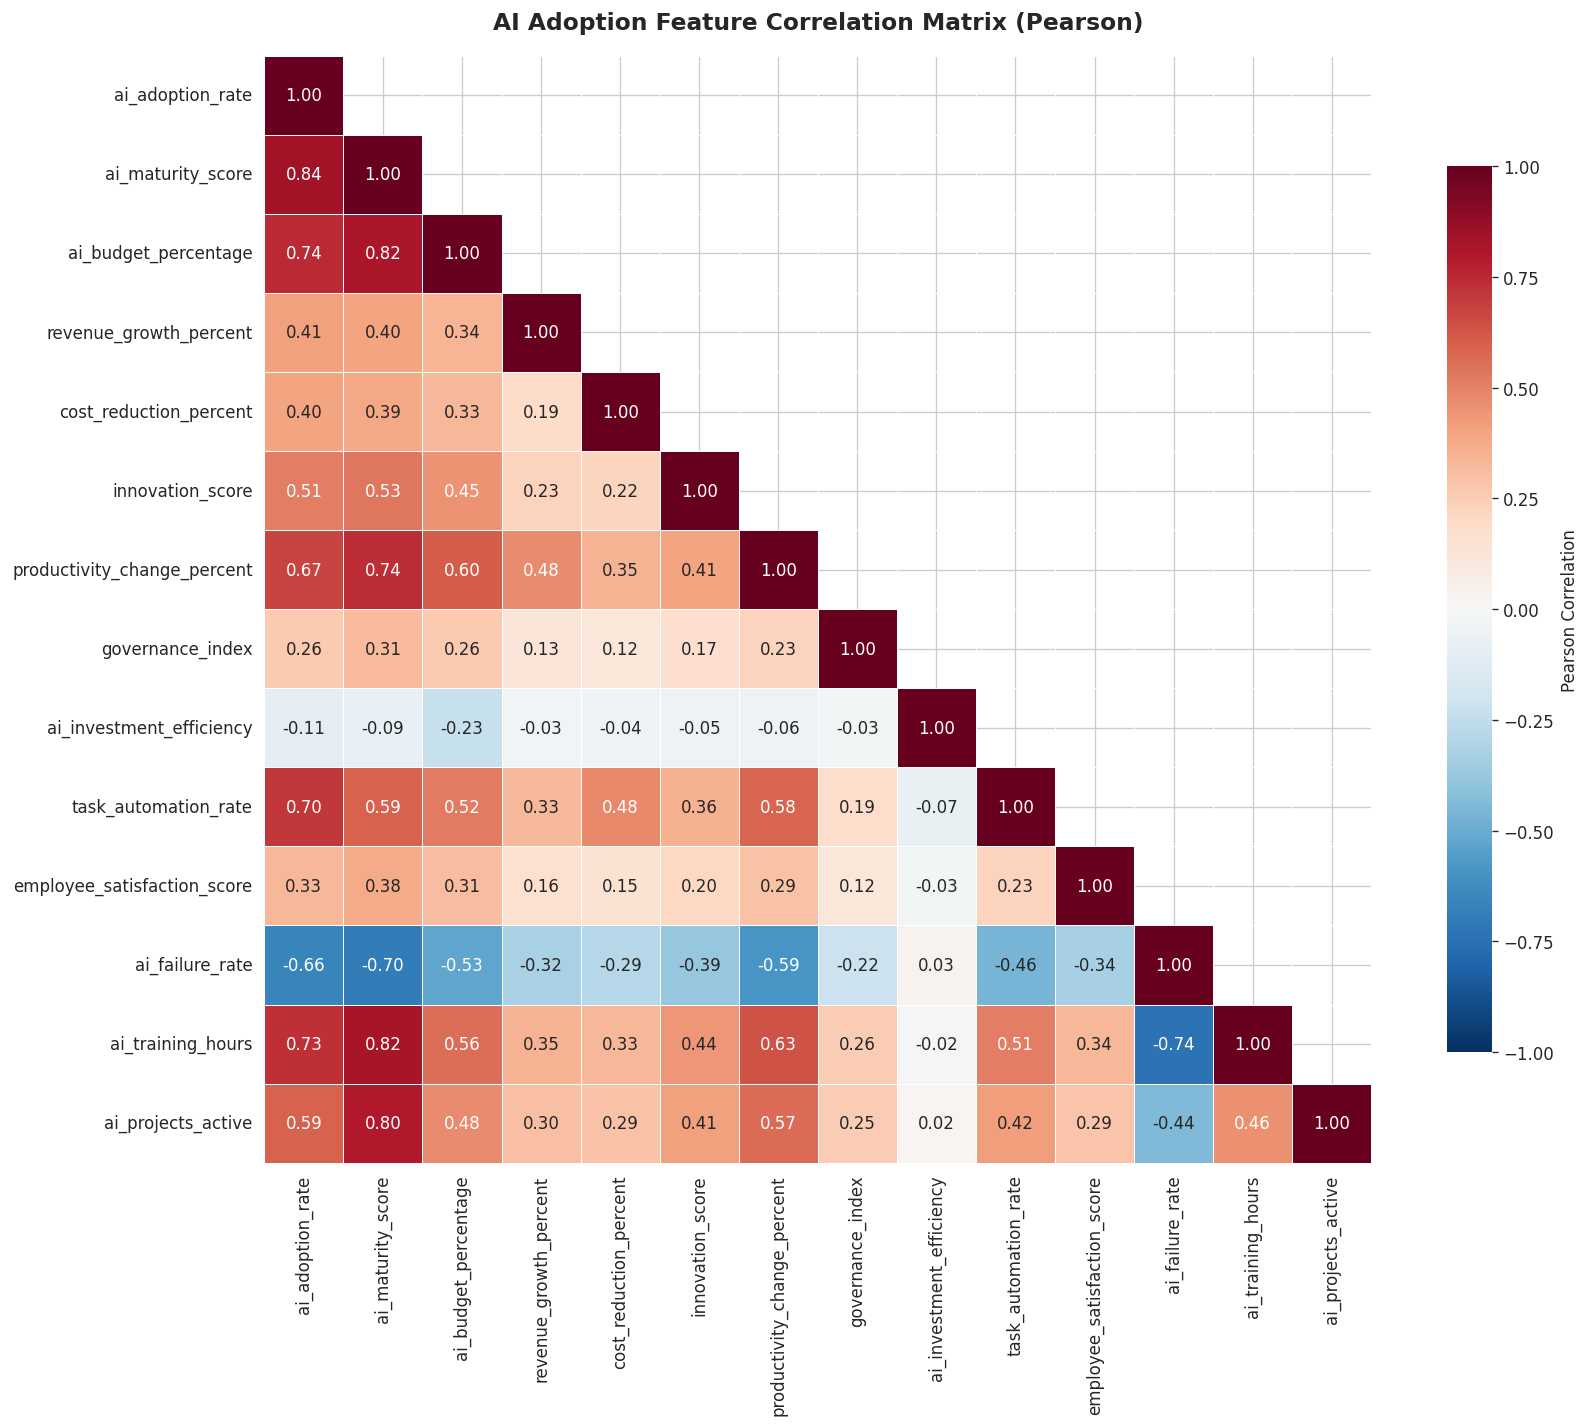

=== Top Feature Correlations with Revenue Growth ===
  productivity_change_percent         r =  0.476  (moderate positive)
  ai_adoption_rate                    r =  0.407  (moderate positive)
  ai_maturity_score                   r =  0.403  (moderate positive)
  ai_training_hours                   r =  0.348  (moderate positive)
  ai_budget_percentage                r =  0.341  (moderate positive)
  task_automation_rate                r =  0.327  (moderate positive)
  ai_failure_rate                     r = -0.322  (moderate negative)
  ai_projects_active                  r =  0.300  (weak positive)
  innovation_score                    r =  0.231  (weak positive)
  cost_reduction_percent              r =  0.191  (weak positive)
  employee_satisfaction_score         r =  0.158  (weak positive)
  governance_index                    r =  0.131  (weak positive)
  ai_investment_efficiency            r = -0.033  (weak negative)


In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

# --- Part A: Pearson Correlation Matrix ---
corr_features = [
    'ai_adoption_rate', 'ai_maturity_score', 'ai_budget_percentage',
    'revenue_growth_percent', 'cost_reduction_percent', 'innovation_score',
    'productivity_change_percent', 'governance_index', 'ai_investment_efficiency',
    'task_automation_rate', 'employee_satisfaction_score', 'ai_failure_rate',
    'ai_training_hours', 'ai_projects_active'
]

corr_assembler = VectorAssembler(inputCols=corr_features, outputCol='corr_vector', handleInvalid='skip')
df_corr = corr_assembler.transform(df_fe)

# Compute Pearson correlation — returns DataFrame with 1 row containing the matrix
pearson_result = Correlation.corr(df_corr, 'corr_vector', 'pearson').head()
corr_array = pearson_result[0].toArray()
corr_pd = pd.DataFrame(corr_array, index=corr_features, columns=corr_features)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_pd, dtype=bool), k=1)
sns.heatmap(corr_pd, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8}, ax=ax)
ax.set_title('AI Adoption Feature Correlation Matrix (Pearson)', fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

# Extract top correlations with revenue_growth_percent (absolute value)
print('=== Top Feature Correlations with Revenue Growth ===')
rev_corr = corr_pd['revenue_growth_percent'].drop('revenue_growth_percent')
rev_corr_sorted = rev_corr.reindex(rev_corr.abs().sort_values(ascending=False).index)
for feat, val in rev_corr_sorted.items():
    direction = 'positive' if val > 0 else 'negative'
    strength = 'strong' if abs(val) > 0.5 else 'moderate' if abs(val) > 0.3 else 'weak'
    print(f'  {feat:<35s} r = {val:>6.3f}  ({strength} {direction})')

In [ ]:
from pyspark.ml.stat import ChiSquareTest
from pyspark.ml.feature import StringIndexer

# --- Part B: Chi-Square Test — categorical association with high_adopter ---
print('=== Chi-Square Test: Feature Association with High AI Adoption ===')
print('H0: The categorical feature is independent of high-adopter status')
print()

chi_cat_cols = ['industry', 'company_size', 'ai_adoption_stage',
                'ai_ethics_committee', 'region', 'data_privacy_level']

# Index categorical columns
df_chi = df_fe
for c in chi_cat_cols:
    indexer = StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
    df_chi = indexer.fit(df_chi).transform(df_chi)

# Assemble categorical features into vector
chi_assembler = VectorAssembler(
    inputCols=[f'{c}_idx' for c in chi_cat_cols],
    outputCol='chi_features',
    handleInvalid='skip'
)
df_chi = chi_assembler.transform(df_chi)

# Run Chi-square test against high_adopter label
chi_result = ChiSquareTest.test(df_chi, 'chi_features', 'high_adopter')
chi_pd = chi_result.select('pValues', 'degreesOfFreedom', 'statistics').toPandas()

print(f'  {"Feature":<28s} {"Chi2":>10s} {"df":>5s} {"p-value":>12s}  {"Result"}')
print(f'  {"-"*72}')
for i, c in enumerate(chi_cat_cols):
    p_val = chi_pd['pValues'].iloc[0][i]
    dof = chi_pd['degreesOfFreedom'].iloc[0][i]
    stat = chi_pd['statistics'].iloc[0][i]
    if p_val < 0.001:
        sig = 'SIGNIFICANT (p<0.001) ***'
    elif p_val < 0.01:
        sig = 'SIGNIFICANT (p<0.01)  **'
    elif p_val < 0.05:
        sig = 'SIGNIFICANT (p<0.05)  *'
    else:
        sig = 'not significant'
    print(f'  {c:<28s} {stat:>10.2f} {int(dof):>5d} {p_val:>12.6f}  {sig}')

print()
print('Chi-square confirms: industry, company_size, adoption_stage, and ethics_committee')
print('are all statistically significant predictors of high AI adoption status.')

=== Chi-Square Test: Feature Association with High AI Adoption ===
H0: The categorical feature is independent of high-adopter status

  Feature                            Chi2    df      p-value  Result
  ------------------------------------------------------------------------
  industry                        3091.85     8     0.000000  SIGNIFICANT (p<0.001) ***
  company_size                    4433.95     2     0.000000  SIGNIFICANT (p<0.001) ***
  ai_adoption_stage              33127.11     3     0.000000  SIGNIFICANT (p<0.001) ***
  ai_ethics_committee             1986.33     1     0.000000  SIGNIFICANT (p<0.001) ***
  region                           659.75     5     0.000000  SIGNIFICANT (p<0.001) ***
  data_privacy_level                 1.12     2     0.571595  not significant

Chi-square confirms: industry, company_size, adoption_stage, and ethics_committee
are all statistically significant predictors of high AI adoption status.



## 10. Binary Classification — High Adopter Prediction


In [ ]:
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Features for classification (excluding target-leakage columns)
class_features = [
    'ai_budget_percentage', 'ai_training_hours', 'num_ai_tools_used',
    'ai_projects_active', 'ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score',
    'remote_work_percentage', 'employee_satisfaction_score',
    'task_automation_rate', 'productivity_change_percent',
    'innovation_score', 'governance_index',
    'ai_investment_efficiency', 'productivity_per_ai_tool',
    'automation_leverage', 'has_ethics_committee', 'years_using_ai'
]

# Assemble & scale
class_assembler = VectorAssembler(inputCols=class_features, outputCol='class_raw', handleInvalid='skip')
class_scaler = StandardScaler(inputCol='class_raw', outputCol='class_features', withStd=True, withMean=True)

# Build pipeline
from pyspark.ml import Pipeline as MLPipeline
class_prep = MLPipeline(stages=[class_assembler, class_scaler])
df_class = class_prep.fit(df_fe).transform(df_fe).select('class_features', 'high_adopter')

# Train/test split
train_cls, test_cls = df_class.randomSplit([0.8, 0.2], seed=42)
print(f'Training: {train_cls.count():,}  |  Test: {test_cls.count():,}')
print(f'High Adopter ratio — Train: {train_cls.filter("high_adopter = 1").count() / train_cls.count():.3f}  |  Test: {test_cls.filter("high_adopter = 1").count() / test_cls.count():.3f}')

Training: 119,936  |  Test: 30,064
High Adopter ratio — Train: 0.176  |  Test: 0.180


=== Model 1: Logistic Regression ===
  AUC = 0.9550  |  Accuracy = 0.9093  |  Precision = 0.9245  |  Recall = 0.9685

=== Model 2: Gradient-Boosted Trees ===
  AUC = 0.9506  |  Accuracy = 0.9055  |  Precision = 0.9291  |  Recall = 0.9578

=== Classification Model Comparison ===


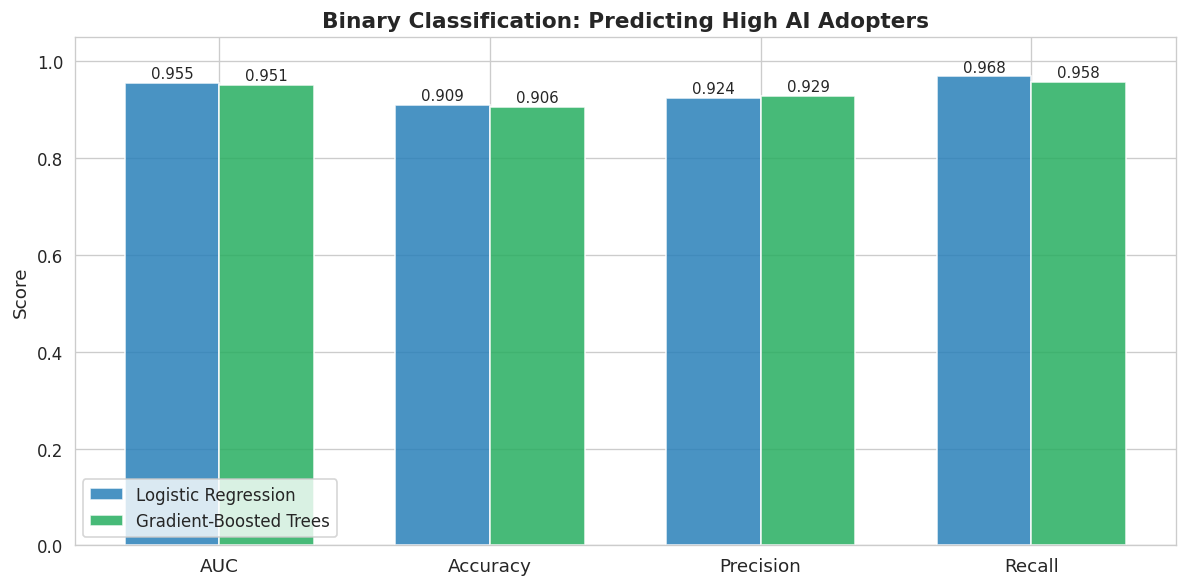

In [ ]:
# --- Model 1: Logistic Regression ---
print('=== Model 1: Logistic Regression ===')
lr = LogisticRegression(
    featuresCol='class_features', labelCol='high_adopter',
    maxIter=50, regParam=0.01, elasticNetParam=0.5, family='binomial'
)
lr_model = lr.fit(train_cls)
lr_preds = lr_model.transform(test_cls)

# Evaluate LR
lr_auc = BinaryClassificationEvaluator(labelCol='high_adopter', metricName='areaUnderROC').evaluate(lr_preds)
lr_acc = MulticlassClassificationEvaluator(labelCol='high_adopter', metricName='accuracy').evaluate(lr_preds)
lr_prec = MulticlassClassificationEvaluator(labelCol='high_adopter', metricName='precisionByLabel').evaluate(lr_preds)
lr_rec = MulticlassClassificationEvaluator(labelCol='high_adopter', metricName='recallByLabel').evaluate(lr_preds)
print(f'  AUC = {lr_auc:.4f}  |  Accuracy = {lr_acc:.4f}  |  Precision = {lr_prec:.4f}  |  Recall = {lr_rec:.4f}')

# --- Model 2: Gradient-Boosted Trees ---
print('\n=== Model 2: Gradient-Boosted Trees ===')
gbt = GBTClassifier(
    featuresCol='class_features', labelCol='high_adopter',
    maxIter=30, maxDepth=6, subsamplingRate=0.8, seed=42, stepSize=0.1
)
gbt_model = gbt.fit(train_cls)
gbt_preds = gbt_model.transform(test_cls)

# Evaluate GBT
gbt_auc = BinaryClassificationEvaluator(labelCol='high_adopter', metricName='areaUnderROC').evaluate(gbt_preds)
gbt_acc = MulticlassClassificationEvaluator(labelCol='high_adopter', metricName='accuracy').evaluate(gbt_preds)
gbt_prec = MulticlassClassificationEvaluator(labelCol='high_adopter', metricName='precisionByLabel').evaluate(gbt_preds)
gbt_rec = MulticlassClassificationEvaluator(labelCol='high_adopter', metricName='recallByLabel').evaluate(gbt_preds)
print(f'  AUC = {gbt_auc:.4f}  |  Accuracy = {gbt_acc:.4f}  |  Precision = {gbt_prec:.4f}  |  Recall = {gbt_rec:.4f}')

# --- Side-by-side comparison ---
print('\n=== Classification Model Comparison ===')
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall']
lr_scores = [lr_auc, lr_acc, lr_prec, lr_rec]
gbt_scores = [gbt_auc, gbt_acc, gbt_prec, gbt_rec]
x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#2980B9', alpha=0.85)
bars2 = ax.bar(x + width/2, gbt_scores, width, label='Gradient-Boosted Trees', color='#27AE60', alpha=0.85)
for bar, val in zip(bars1, lr_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
for bar, val in zip(bars2, gbt_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Binary Classification: Predicting High AI Adopters', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 11. MLlib Pipeline — RandomForest Regression (AI Maturity Prediction)



In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor

# Feature columns (excluding target and leakage columns)
numeric_features = [
    'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used',
    'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
    'ai_failure_rate', 'ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score',
    'remote_work_percentage', 'employee_satisfaction_score',
    'task_automation_rate', 'productivity_change_percent',
    'jobs_displaced', 'jobs_created', 'reskilled_employees',
    'innovation_score', 'governance_index',
    'ai_investment_efficiency', 'productivity_per_ai_tool',
    'automation_leverage', 'has_ethics_committee'
]
categorical_features = ['industry', 'company_size', 'ai_adoption_stage']

# Stage 1: StringIndexer
indexers = [StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
            for c in categorical_features]

# Stage 2: VectorAssembler
assembler_input = [f'{c}_idx' for c in categorical_features] + numeric_features
assembler = VectorAssembler(inputCols=assembler_input, outputCol='raw_features', handleInvalid='skip')

# Stage 3: StandardScaler
scaler = StandardScaler(inputCol='raw_features', outputCol='scaled_features', withStd=True, withMean=True)

# Stage 4: RandomForestRegressor
rf = RandomForestRegressor(
    featuresCol='scaled_features', labelCol='ai_maturity_score',
    numTrees=50, maxDepth=10, subsamplingRate=0.8, seed=42, featureSubsetStrategy='sqrt'
)

# Build & fit Pipeline
pipeline = Pipeline(stages=indexers + [assembler, scaler, rf])
train_df, test_df = df_fe.randomSplit([0.8, 0.2], seed=42)
print(f'Training: {train_df.count():,}  |  Test: {test_df.count():,}')

model = pipeline.fit(train_df)
print('Pipeline fitted — all 4 stages complete.')

Training: 119,936  |  Test: 30,064
Pipeline fitted — all 4 stages complete.


RMSE = 0.0168  |  R2 = 0.9843  |  MAE = 0.0123


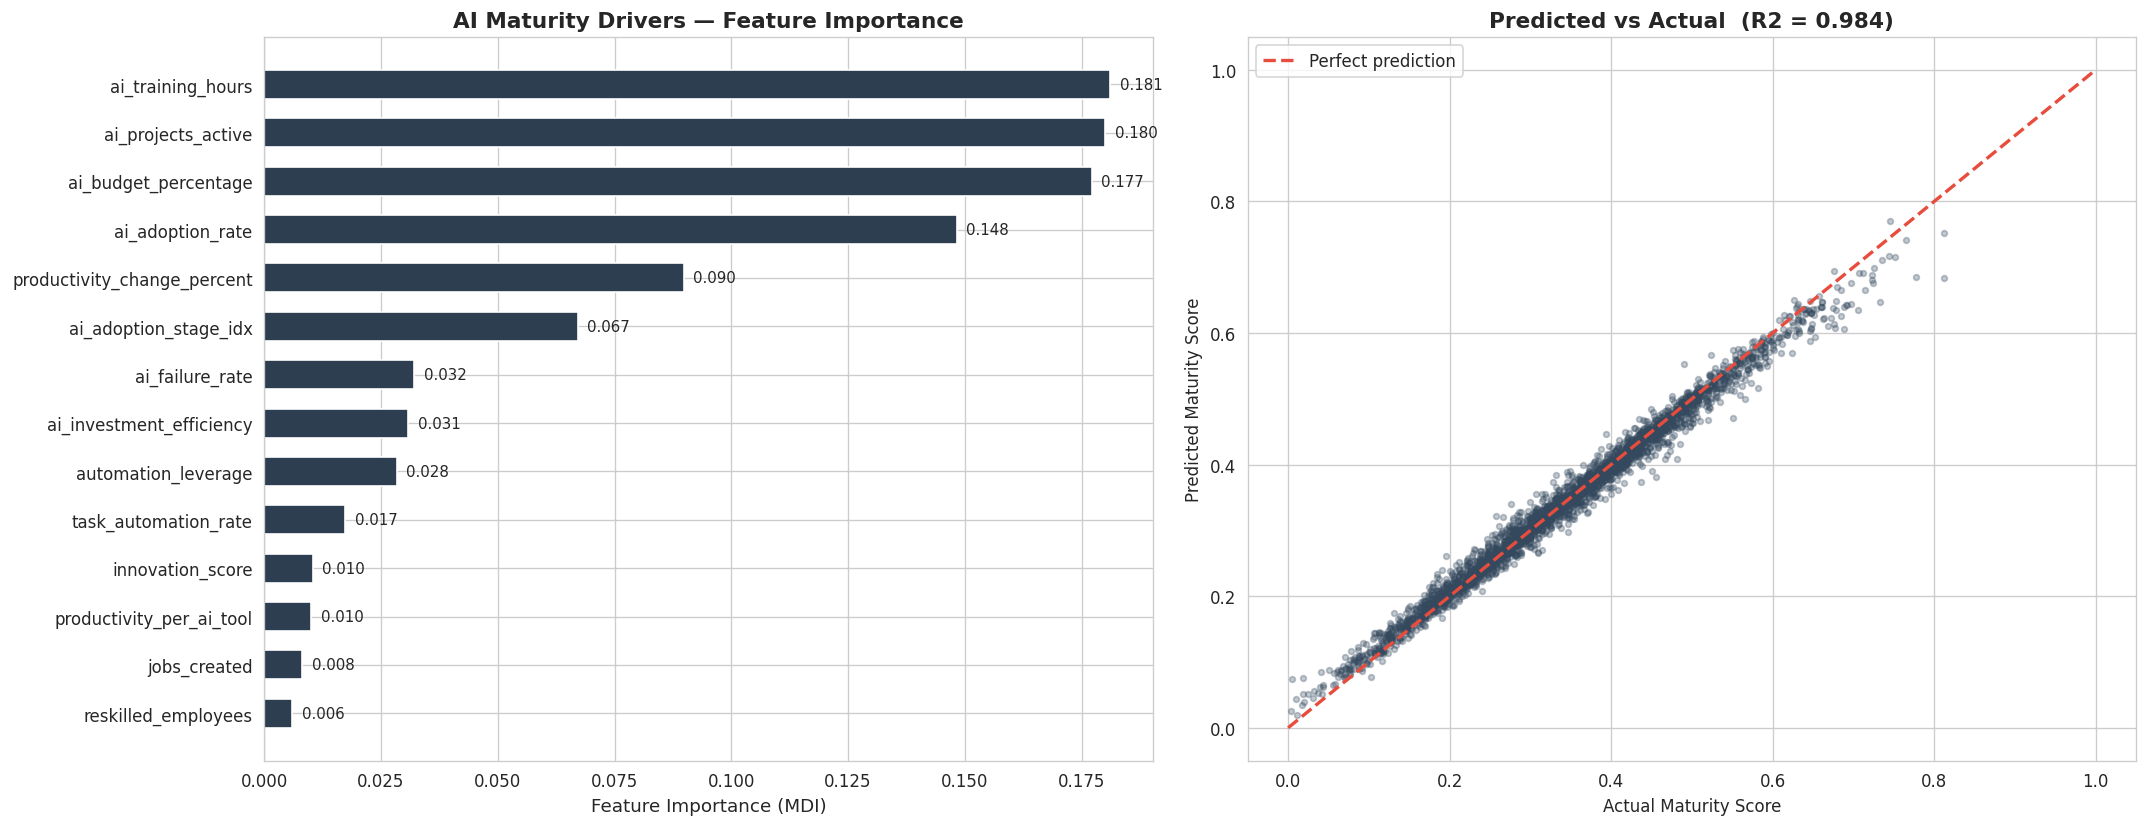

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test_df)

# 3-metric evaluation
rmse = RegressionEvaluator(labelCol='ai_maturity_score', predictionCol='prediction', metricName='rmse').evaluate(predictions)
r2   = RegressionEvaluator(labelCol='ai_maturity_score', predictionCol='prediction', metricName='r2').evaluate(predictions)
mae  = RegressionEvaluator(labelCol='ai_maturity_score', predictionCol='prediction', metricName='mae').evaluate(predictions)

print(f'RMSE = {rmse:.4f}  |  R2 = {r2:.4f}  |  MAE = {mae:.4f}')

# --- Feature Importance ---
rf_model = model.stages[-1]
importances = rf_model.featureImportances
imp_tuples = sorted(zip(assembler_input, importances.toArray()), key=lambda x: x[1], reverse=True)
imp_pd = pd.DataFrame(imp_tuples, columns=['feature', 'importance'])
imp_pd = imp_pd[imp_pd['importance'] > 0.005]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: feature importance
bars = ax1.barh(range(len(imp_pd)), imp_pd['importance'].values, color='#2C3E50', height=0.6)
ax1.set_yticks(range(len(imp_pd)))
ax1.set_yticklabels(imp_pd['feature'].values, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Feature Importance (MDI)', fontsize=11)
ax1.set_title('AI Maturity Drivers — Feature Importance', fontsize=13, fontweight='bold')
for bar, val in zip(bars, imp_pd['importance'].values):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)

# Right: predicted vs actual
sample_pred = predictions.select('ai_maturity_score', 'prediction').sample(0.1, seed=42).toPandas()
ax2.scatter(sample_pred['ai_maturity_score'], sample_pred['prediction'], alpha=0.3, s=12, color='#34495E')
ax2.plot([0, 1], [0, 1], '--', color='#E74C3C', lw=2, label='Perfect prediction')
ax2.set_xlabel('Actual Maturity Score')
ax2.set_ylabel('Predicted Maturity Score')
ax2.set_title(f'Predicted vs Actual  (R2 = {r2:.3f})', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


## 12. Pandas API on Spark


Pandas-on-Spark shape: 150,000 x 58

=== Industry Summary (Pandas API on Spark) ===
               avg_adoption  avg_maturity  avg_investment_efficiency  avg_governance  total_firms  avg_revenue_growth
industry                                                                                                             
Technology            42.47          0.41                       0.03           65.89         1408                5.63
Finance               38.35          0.35                       0.04           65.14         1344                4.83
Education             35.23          0.33                       0.04           64.96         1014                4.31
Healthcare            34.57          0.33                       0.05           64.55         1240                4.23
Agriculture           35.25          0.33                       0.04           64.80         1038                4.39
Consulting            34.52          0.33                       0.05           64.71      

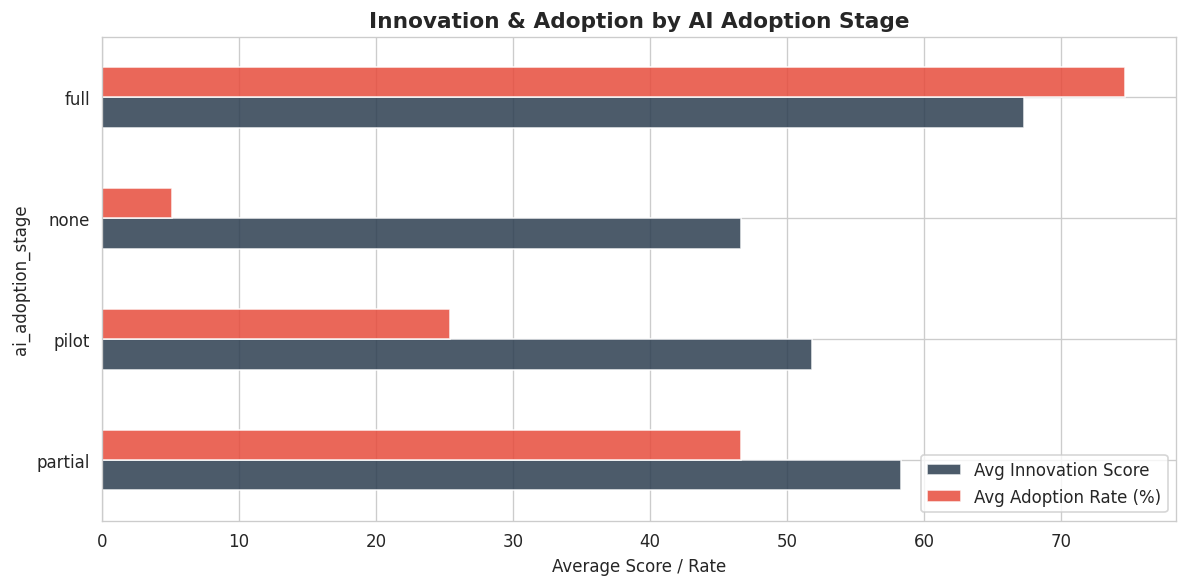

In [ ]:
import pyspark.pandas as ps

# Convert Spark DF -> Pandas-on-Spark (lazy — zero data movement)
psdf = ps.DataFrame(df_fe)
print(f'Pandas-on-Spark shape: {psdf.shape[0]:,} x {psdf.shape[1]}')

# Pandas-style groupby — compiled to Spark jobs under the hood
print('\n=== Industry Summary (Pandas API on Spark) ===')
industry_summary = (psdf
    .groupby('industry')
    .agg(
        avg_adoption=('ai_adoption_rate', 'mean'),
        avg_maturity=('ai_maturity_score', 'mean'),
        avg_investment_efficiency=('ai_investment_efficiency', 'mean'),
        avg_governance=('governance_index', 'mean'),
        total_firms=('company_id', 'nunique'),
        avg_revenue_growth=('revenue_growth_percent', 'mean')
    )
    .round(2)
    .sort_values('avg_maturity', ascending=False)
)
print(industry_summary.head(12).to_string())

# Round-trip: Pandas-on-Spark -> native Spark DataFrame
spark_again = industry_summary.to_spark()
print(f'\nRound-tripped to Spark DataFrame: {spark_again.count()} rows')

# Pandas-native chain plotting
fig = (psdf
    .groupby('ai_adoption_stage')
    .agg(
        avg_innovation=('innovation_score', 'mean'),
        avg_adoption=('ai_adoption_rate', 'mean'),
        n=('company_id', 'count')
    )
    .sort_values('n', ascending=False).head(6)
    .reset_index().to_pandas()
    .plot(kind='barh', x='ai_adoption_stage', y=['avg_innovation', 'avg_adoption'],
          figsize=(10, 5), color=['#2C3E50', '#E74C3C'], alpha=0.85)
)
plt.title('Innovation & Adoption by AI Adoption Stage', fontsize=13, fontweight='bold')
plt.xlabel('Average Score / Rate')
plt.legend(['Avg Innovation Score', 'Avg Adoption Rate (%)'])
plt.tight_layout()
plt.show()